<a href="https://colab.research.google.com/github/errodd/Houses-Prices---ML-/blob/EDA/notebooks/EDA_HousesPrices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Iniciamos el exploratory data analysis(EDA) importando las librerias necesarias para las operaciones que vamos a ejecutar:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold
from scipy.stats import chi2_contingency

#from scipy import stats

# Improve Pandas table display
pd.set_option("display.max_columns", 81)
pd.set_option("display.width", 120)

2. Cargamos el dataset de precios de casas en un dataframe de Pandas llamado df, usando el atributo df.shape observamos que el tamaño del dataset es de 2919 filas y 81 columnas:

In [ ]:
url = 'https://raw.githubusercontent.com/errodd/Houses-Prices---ML-/refs/heads/EDA/data/houses_prices.csv'
df = pd.read_csv(url)
df.shape

(2919, 81)

3. Usamos el comando df.head para observar las caracteristicas de las primeros 5 casas(filas) y las ultimas 5 casas(filas) ordenadas por numero de identificación.
Hacemos una copia de los datos del dataset(df) y la almacenamos en el dataframe all_data

In [ ]:
df.head()
all_data = df.copy()
all_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
2915,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
2916,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN
2917,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,

4. Usando este comando(isnull().any()) observamos que caracteristicas no estan presentes en por lo menos una casa del dataset, es decir, las caracteristicas que no sean conocidas(o no sean validas) en por lo menos una casa del dataset.

In [ ]:
all_data.isnull().any()

,0
Id,False
MSSubClass,False
MSZoning,True
LotFrontage,True
LotArea,False
...,...
MoSold,False
YrSold,False
SaleType,True
SaleCondition,False


5. Dado que la caracteristica Id no nos sirve para poder hacer el modelo, lo eliminas de nuestro dataframe llamado all.data mediante un comando.

In [ ]:
all_data.drop('Id',axis=1,inplace=True)


6. Como observamos previamente(En el paso 4), algunas casas no tienen precio de venta(SalePrice), dado que esa es nuestra variable objetivo(target), no nos sirven las casas que no dispongan de precio de venta y por lo tanto las podemos eliminar del dataset(all_data).

In [ ]:
all_data.dropna(subset=['SalePrice'], inplace=True)
all_data.isnull().any()

,0
MSSubClass,False
MSZoning,False
LotFrontage,True
LotArea,False
Street,False
...,...
MoSold,False
YrSold,False
SaleType,False
SaleCondition,False


7. Aqui podemos observar que el tamaño del dataset(all_data) ahora es de 1460 filas por 80 columnas, eliminamos la columna Id y eliminamos 1459 filas, las que no tenian precio de venta(SalePrice).

In [ ]:
all_data.shape

(1460, 80)

8. Buscamos las caracteristicas(columnas) en las cuales muchas casas(mas del 50%) no tengan valores(lo tengan en null):

In [ ]:
data_row_null = (all_data.isna().mean() * 100).sort_values(ascending=False)
data_row_null_above50 = data_row_null[data_row_null.between(50,100, inclusive="both")]
data_row_null_above50

,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027


9. Eliminamos esas 5 caracteristicas(columnas) del dataset debido a que podemos concluir que no van a brindar información concreta al modelo.

In [ ]:
all_data = all_data.drop(data_row_null_above50.index, axis=1)
all_data.shape

(1460, 75)

10. Tomamos del dataset(all_data) las columnas de tipo numericas, es decir, que contengan valores reales y enteros y las copiamos a un dataframe llamado numeric_columns

In [ ]:
all_data.dtypes.value_counts()

,count
object,38
int64,25
float64,12


In [ ]:
numeric_columns = all_data.select_dtypes(['int64', 'float64']).columns
numeric_columns, len(numeric_columns)

(Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea',
        'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
        'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
        'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
        '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
       dtype='object'),
 37)

11. Ahora tomamos del dataset(all_data) las columnas de tipo cadena(string) y las copiamos a un dataframe llamado string_columns

In [ ]:
string_columns = all_data.select_dtypes(exclude=['int64', 'float64']).columns
string_columns, len(string_columns)

(Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',
        'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
        'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
        'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType',
        'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
       dtype='object'),
 38)

12. El paso 10 se realizo para poder calcular la correlación de las columnas numericas con el precio de venta(SalePrice), para determinar que caracteristicas(columnas) son las que mas afectan el precio de venta para el modelo. En este caso un numero cercano a 1 en la correlacion de la caracteristica implica correlación positiva que significa que mientras suba esta caracteristica sube el precio de venta. Un numero cercano a -1 en la correlacion de la caracteristica implica correlación negativa que significa que mientras suba esta caracteristica baja el precio de venta. Por ultimo un numero cercano a 0 implica que no existe correlación lineal entre esa caracteristica y el precio de venta.

In [ ]:
# correlation with our target
cor_numeric = df[numeric_columns].corr()
cor_target = cor_numeric.sort_values(['SalePrice'],ascending=False)
cor_target.SalePrice, len(numeric_columns)

(SalePrice        1.000000
 OverallQual      0.790982
 GrLivArea        0.708624
 GarageCars       0.640409
 GarageArea       0.623431
 TotalBsmtSF      0.613581
 1stFlrSF         0.605852
 FullBath         0.560664
 TotRmsAbvGrd     0.533723
 YearBuilt        0.522897
 YearRemodAdd     0.507101
 GarageYrBlt      0.486362
 MasVnrArea       0.477493
 Fireplaces       0.466929
 BsmtFinSF1       0.386420
 LotFrontage      0.351799
 WoodDeckSF       0.324413
 2ndFlrSF         0.319334
 OpenPorchSF      0.315856
 HalfBath         0.284108
 LotArea          0.263843
 BsmtFullBath     0.227122
 BsmtUnfSF        0.214479
 BedroomAbvGr     0.168213
 ScreenPorch      0.111447
 PoolArea         0.092404
 MoSold           0.046432
 3SsnPorch        0.044584
 BsmtFinSF2      -0.011378
 BsmtHalfBath    -0.016844
 MiscVal         -0.021190
 LowQualFinSF    -0.025606
 YrSold          -0.028923
 OverallCond     -0.077856
 MSSubClass      -0.084284
 EnclosedPorch   -0.128578
 KitchenAbvGr    -0.135907
 

13. Examinamos las caracteristicas(columnas) con baja correlación( < 0.4) con el precio de venta(SalePrice).

In [ ]:
cor_bad = cor_target.SalePrice[cor_target.SalePrice.between(-0.4,0.4, inclusive="both")]
cor_bad, len(cor_bad)

(BsmtFinSF1       0.386420
 LotFrontage      0.351799
 WoodDeckSF       0.324413
 2ndFlrSF         0.319334
 OpenPorchSF      0.315856
 HalfBath         0.284108
 LotArea          0.263843
 BsmtFullBath     0.227122
 BsmtUnfSF        0.214479
 BedroomAbvGr     0.168213
 ScreenPorch      0.111447
 PoolArea         0.092404
 MoSold           0.046432
 3SsnPorch        0.044584
 BsmtFinSF2      -0.011378
 BsmtHalfBath    -0.016844
 MiscVal         -0.021190
 LowQualFinSF    -0.025606
 YrSold          -0.028923
 OverallCond     -0.077856
 MSSubClass      -0.084284
 EnclosedPorch   -0.128578
 KitchenAbvGr    -0.135907
 Name: SalePrice, dtype: float64,
 23)

14. Eliminamos las caracteristicas(columnas) con baja correlación( < 0.4) con el precio de venta(SalePrice) del dataset all_data debido a que estas no explican de manera significativa el precio de venta(SalePrice), asi que para este modelo serian irrelevantes.

In [ ]:
all_data = all_data.drop(cor_bad.index, axis=1)
all_data.shape

(1460, 52)

In [ ]:
all_data.dtypes.value_counts()

,count
object,38
int64,8
float64,6


15. Observamos la cantidad de valores unicos en cada columna del dataframe que contiene solo valores tipo cadena(str) para determinar que caracteristicas son categorias y cuales no. Dado que no hay valor que exceda los 100, podemos concluir facilmente que todas estas columnas son categorias.

In [ ]:
all_data

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,GrLivArea,FullBath,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition,SalePrice
0,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,2003,2003,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,Unf,856.0,GasA,Ex,Y,SBrkr,856,1710,2,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,WD,Normal,208500.0
1,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,1976,1976,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,Unf,1262.0,GasA,Ex,Y,SBrkr,1262,1262,2,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,WD,Normal,181500.0
2,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,2001,2002,Gable,CompShg,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,Unf,920.0,GasA,Ex,Y,SBrkr,920,1786,2,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,WD,Normal,223500.0
3,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,Unf,756.0,GasA,Gd,Y,SBrkr,961,1717,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,WD,Abnorml,140000.0
4,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,2000,2000,Gable,CompShg,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,Unf,1145.0,GasA,Ex,Y,SBrkr,1145,2198,2,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,1999,2000,Gable,CompShg,VinylSd,VinylSd,0.0,TA,TA,PConc,Gd,TA,No,Unf,Unf,953.0,GasA,Ex,Y,SBrkr,953,1647,2,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2.0,460.0,TA,TA,Y,WD,Normal,175000.0
1456,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,1978,1988,Gable,CompShg,Plywood,Plywood,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,Rec,1542.0,GasA,TA,Y,SBrkr,2073,2073,2,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2.0,500.0,TA,TA,Y,WD,Normal,210000.0
1457,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,1941,2006,Gable,CompShg,CemntBd,CmentBd,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,Unf,1152.0,GasA,Ex,Y,SBrkr,1188,2340,2,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1.0,252.0,TA,TA,Y,WD,Normal,266500.0
1458,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,1950,1996,Hip,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,Rec,1078.0,GasA,Gd,Y,FuseA,1078,1078,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1.0,240.0,TA,TA,Y,WD,Normal,142125.0


In [ ]:
all_data[string_columns].nunique().sort_values(ascending=False)

,0
Neighborhood,25
Exterior2nd,16
Exterior1st,15
Condition1,9
SaleType,9
RoofMatl,8
Condition2,8
HouseStyle,8
Functional,7
BsmtFinType2,6


16. Definimos funciones para hacer analisis estadistico de cada categoria, incluyendo prueba ji-cuadrada para revisar la relacion con la variable objetivo

In [ ]:
def analyze_categorical_features(df, categorical_cols, target):
    analysis = []

    for col in categorical_cols:
        stats = {
            'column': col,
            'unique_values': df[col].nunique(),
            'missing_pct': df[col].isnull().mean() * 100,
            'most_frequent_pct': df[col].value_counts(normalize=True).max() * 100,
            'cardinality_ratio': df[col].nunique() / len(df)
        }

        # Check relationship with target
        if stats['unique_values'] > 2:
            contingency_table = pd.crosstab(df[col], df[target])
            from scipy.stats import chi2_contingency
            chi2, p_value, _, _ = chi2_contingency(contingency_table)
            stats['chi2_p_value'] = p_value
            stats['significant'] = p_value < 0.05

        analysis.append(stats)

    return pd.DataFrame(analysis).sort_values('unique_values')

def decide_encoding_method(row):
    """
    row contains: unique_values, missing_pct, most_frequent_pct,
                  cardinality_ratio, significant
    """
    # Low cardinality (2-4 values)
    if row[row['unique_values'] <= 4]:
        if row[row['significant']]:
            return "One-Hot Encoding (preserve important categories)"
        else:
            return "Frequency Encoding or Binary Encoding"

    # Medium cardinality (5-10 values)
    elif row[row['unique_values'] <= 10]:
        if row[row['most_frequent_pct'] > 80]:  # Skewed distribution
            return "One-Hot + Target Encoding (keep frequent, encode others)"
        else:
            return "Target Encoding with cross-validation"

    # High cardinality (11-25 values)
    else:
        if row[row['cardinality_ratio'] > 0.1]:  # Many unique values relative to data
            return "Target Encoding with smoothing + CV"
        else:
            return "Binary Encoding or Target Encoding"
def hybrid_encode_multiple_columns(df, categorical_cols, target, oh_threshold=0.05):
    """
    Apply hybrid encoding to multiple categorical columns
    """
    df_encoded = df.copy()

    for col in categorical_cols:
        print(f"Encoding {col}...")

        # Calculate frequency
        freq = df[col].value_counts(normalize=True)
        oh_cats = freq[freq >= oh_threshold].index.tolist()

        # One-hot encode frequent categories
        for cat in oh_cats:
            df_encoded[f'{col}_oh_{cat}'] = (df[col] == cat).astype(int)

        # Target encode the rest (including 'Other' group)
        # Group rare categories
        df_encoded[f'{col}_grouped'] = df[col].apply(
            lambda x: x if x in oh_cats else 'Other'
        )

        # Calculate target means with smoothing
        global_mean = df[target].mean()

        # Group statistics
        stats = df_encoded.groupby(f'{col}_grouped')[target].agg(['count', 'mean'])

        # Apply smoothing (more smoothing for smaller groups)
        stats['smoothed'] = (
            (stats['count'] * stats['mean'] + 10 * global_mean) /
            (stats['count'] + 10)
        )

        # Map to dataframe
        df_encoded[f'{col}_te'] = df_encoded[f'{col}_grouped'].map(stats['smoothed'])

        # Drop temporary column
        df_encoded.drop(f'{col}_grouped', axis=1, inplace=True)

    return df_encoded

class AdvancedCVTargetEncoder:
    def __init__(self, n_folds=5, smoothing_params=None):
        self.n_folds = n_folds
        self.smoothing_params = smoothing_params or {}  # Column-specific smoothing
        self.encodings_ = {}
        self.global_means_ = {}

    def fit_transform(self, X, y, categorical_columns):
        """
        Apply target encoding with CV to multiple columns

        Parameters:
        X: DataFrame with features
        y: Series or array with target values
        categorical_columns: list of column names to encode
        """
        X = X.copy()

        # Convert y to Series if it's not already
        if not isinstance(y, pd.Series):
            y = pd.Series(y, index=X.index)

        # Store global mean
        global_mean = y.mean()
        for col in categorical_columns:
            self.global_means_[col] = global_mean

        # Set up cross-validation
        cv = StratifiedKFold(n_splits=self.n_folds, shuffle=True, random_state=42)

        # Initialize encoded columns
        encoded_cols = []

        for col in categorical_columns:
            encoded_name = f'{col}_te'
            X[encoded_name] = np.nan
            encoded_cols.append(encoded_name)

            # Get column-specific smoothing
            smoothing = self.smoothing_params.get(col, 10)

            # Cross-validation loop
            for train_idx, val_idx in cv.split(X, y):
                X_train = X.iloc[train_idx]
                y_train = y.iloc[train_idx]

                # Create a temporary DataFrame with the column and target
                train_data = pd.DataFrame({
                    col: X_train[col],
                    'target': y_train
                })

                # Calculate statistics
                stats = train_data.groupby(col)['target'].agg(['count', 'mean']).reset_index()

                # Apply smoothing
                stats['smoothed'] = (
                    (stats['count'] * stats['mean'] + smoothing * self.global_means_[col]) /
                    (stats['count'] + smoothing)
                )

                # Create mapping dictionary
                mapping = dict(zip(stats[col], stats['smoothed']))

                # Map to validation fold
                X.loc[val_idx, encoded_name] = X.loc[val_idx, col].map(mapping)

                # Fill missing with global mean
                X.loc[val_idx, encoded_name] = X.loc[val_idx, encoded_name].fillna(self.global_means_[col])

            # Store full mapping for future use
            full_stats = X.groupby(col)[encoded_name].mean().reset_index()
            self.encodings_[col] = dict(zip(full_stats[col], full_stats[encoded_name]))

        return X[encoded_cols]

    def transform(self, X):
        """Transform new data using stored encodings"""
        X = X.copy()
        encoded_dfs = []

        for col, mapping in self.encodings_.items():
            encoded = X[col].map(mapping).fillna(self.global_means_[col])
            encoded_dfs.append(encoded.rename(f'{col}_te'))

        return pd.concat(encoded_dfs, axis=1)

def binary_encode_manual(df, column):
    """Manual binary encoding for understanding"""
    df = df.copy()

    # Get unique categories and map to integers
    unique_cats = df[column].unique()
    cat_to_int = {cat: i for i, cat in enumerate(unique_cats)}

    # Determine number of binary columns needed
    n_cats = len(unique_cats)
    n_bits = int(np.ceil(np.log2(n_cats)))

    # Convert each integer to binary and split
    binary_encoded = []
    for cat in df[column]:
        int_val = cat_to_int[cat]
        binary = format(int_val, f'0{n_bits}b')
        binary_encoded.append([int(bit) for bit in binary])

    # Create DataFrame with binary columns
    binary_df = pd.DataFrame(
        binary_encoded,
        columns=[f'{column}_bit{i+1}' for i in range(n_bits)],
        index=df.index
    )

    return binary_df

17. Realizamos el analisis estadistico en las columnas que son cadenas(string_columns), aqui podemos observar valores unicos, porcentaje de filas con valores null, porcentaje del valor que es mas frecuente, radio de cardinalidad(valores unicos divididos entre cantidad de filas), valor p resultado de la prueba ji-cuadrado(respecto al precio de venta) y si esta representa una diferencia estadísticamente significativa entre la frecuencia esperada y las frecuencias observadas, todo esto por cada caracteristica(tipo cadena) del dataset.

In [ ]:
data_estadistica = analyze_categorical_features(all_data, string_columns, "SalePrice")
data_estadistica

,column,unique_values,missing_pct,most_frequent_pct,cardinality_ratio,chi2_p_value,significant
1,Street,2,0.000000,99.589041,0.001370,NaN,NaN
4,Utilities,2,0.000000,99.931507,0.001370,NaN,NaN
26,CentralAir,2,0.000000,93.493151,0.001370,NaN,NaN
6,LandSlope,3,0.000000,94.657534,0.002055,1.050864e-01,False
35,PavedDrive,3,0.000000,91.780822,0.002055,9.912800e-01,False
32,GarageFinish,3,5.547945,43.872371,0.002055,1.035589e-09,True
3,LandContour,4,0.000000,89.794521,0.002740,8.674645e-02,False
21,BsmtExposure,4,2.602740,67.018284,0.002740,1.098007e-07,True
19,BsmtQual,4,2.534247,45.607871,0.002740,7.805558e-22,True
28,KitchenQual,4,0.000000,50.342466,0.002740,1.282074e-31,True


18. Antes de hacer la categorización podemos eliminar caracteristicas que no aporten valor a nuestra variable objetivo(SalePrice), estas son, las columnas con baja cardinalidad(entre 2 y tres valores unicos):

In [ ]:
baja_card = data_estadistica[data_estadistica['unique_values'] <= 3]
data_estadistica.drop(data_estadistica[data_estadistica['unique_values'] <= 3].index, axis=0, inplace=True)

all_data = all_data.drop(baja_card['column'], axis=1)
all_data

,MSZoning,LotShape,LandContour,LotConfig,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,TotalBsmtSF,Heating,HeatingQC,Electrical,1stFlrSF,GrLivArea,FullBath,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageCars,GarageArea,GarageQual,GarageCond,SaleType,SaleCondition,SalePrice
0,RL,Reg,Lvl,Inside,CollgCr,Norm,Norm,1Fam,2Story,7,2003,2003,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,Unf,856.0,GasA,Ex,SBrkr,856,1710,2,Gd,8,Typ,0,NaN,Attchd,2003.0,2.0,548.0,TA,TA,WD,Normal,208500.0
1,RL,Reg,Lvl,FR2,Veenker,Feedr,Norm,1Fam,1Story,6,1976,1976,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,Unf,1262.0,GasA,Ex,SBrkr,1262,1262,2,TA,6,Typ,1,TA,Attchd,1976.0,2.0,460.0,TA,TA,WD,Normal,181500.0
2,RL,IR1,Lvl,Inside,CollgCr,Norm,Norm,1Fam,2Story,7,2001,2002,Gable,CompShg,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,Unf,920.0,GasA,Ex,SBrkr,920,1786,2,Gd,6,Typ,1,TA,Attchd,2001.0,2.0,608.0,TA,TA,WD,Normal,223500.0
3,RL,IR1,Lvl,Corner,Crawfor,Norm,Norm,1Fam,2Story,7,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,Unf,756.0,GasA,Gd,SBrkr,961,1717,1,Gd,7,Typ,1,Gd,Detchd,1998.0,3.0,642.0,TA,TA,WD,Abnorml,140000.0
4,RL,IR1,Lvl,FR2,NoRidge,Norm,Norm,1Fam,2Story,8,2000,2000,Gable,CompShg,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,Unf,1145.0,GasA,Ex,SBrkr,1145,2198,2,Gd,9,Typ,1,TA,Attchd,2000.0,3.0,836.0,TA,TA,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Reg,Lvl,Inside,Gilbert,Norm,Norm,1Fam,2Story,6,1999,2000,Gable,CompShg,VinylSd,VinylSd,0.0,TA,TA,PConc,Gd,TA,No,Unf,Unf,953.0,GasA,Ex,SBrkr,953,1647,2,TA,7,Typ,1,TA,Attchd,1999.0,2.0,460.0,TA,TA,WD,Normal,175000.0
1456,RL,Reg,Lvl,Inside,NWAmes,Norm,Norm,1Fam,1Story,6,1978,1988,Gable,CompShg,Plywood,Plywood,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,Rec,1542.0,GasA,TA,SBrkr,2073,2073,2,TA,7,Min1,2,TA,Attchd,1978.0,2.0,500.0,TA,TA,WD,Normal,210000.0
1457,RL,Reg,Lvl,Inside,Crawfor,Norm,Norm,1Fam,2Story,7,1941,2006,Gable,CompShg,CemntBd,CmentBd,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,Unf,1152.0,GasA,Ex,SBrkr,1188,2340,2,Gd,9,Typ,2,Gd,Attchd,1941.0,1.0,252.0,TA,TA,WD,Normal,266500.0
1458,RL,Reg,Lvl,Inside,NAmes,Norm,Norm,1Fam,1Story,5,1950,1996,Hip,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,Rec,1078.0,GasA,Gd,FuseA,1078,1078,1,Gd,5,Typ,0,NaN,Attchd,1950.0,1.0,240.0,TA,TA,WD,Normal,142125.0


In [ ]:
all_data.dtypes.value_counts()

,count
object,32
int64,8
float64,6


19. Podemos también eliminar columnas con un valor p muy elevado(p > 0.1), lo que significa que no afectan notablemente el precio de venta(SalePrice), y por lo tanto no son utiles para el modelo:

In [ ]:
p_bajo = data_estadistica[data_estadistica['chi2_p_value'] > 0.1]
p_bajo = p_bajo[p_bajo['unique_values'] > 3]
data_estadistica.drop(p_bajo.index, axis=0, inplace=True)

all_data = all_data.drop(p_bajo['column'], axis=1)
all_data

,MSZoning,LotShape,LandContour,LotConfig,Neighborhood,Condition2,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,TotalBsmtSF,Heating,Electrical,1stFlrSF,GrLivArea,FullBath,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,GarageQual,SaleType,SaleCondition,SalePrice
0,RL,Reg,Lvl,Inside,CollgCr,Norm,7,2003,2003,196.0,Gd,TA,PConc,Gd,TA,No,856.0,GasA,SBrkr,856,1710,2,Gd,8,0,NaN,2003.0,2.0,548.0,TA,WD,Normal,208500.0
1,RL,Reg,Lvl,FR2,Veenker,Norm,6,1976,1976,0.0,TA,TA,CBlock,Gd,TA,Gd,1262.0,GasA,SBrkr,1262,1262,2,TA,6,1,TA,1976.0,2.0,460.0,TA,WD,Normal,181500.0
2,RL,IR1,Lvl,Inside,CollgCr,Norm,7,2001,2002,162.0,Gd,TA,PConc,Gd,TA,Mn,920.0,GasA,SBrkr,920,1786,2,Gd,6,1,TA,2001.0,2.0,608.0,TA,WD,Normal,223500.0
3,RL,IR1,Lvl,Corner,Crawfor,Norm,7,1915,1970,0.0,TA,TA,BrkTil,TA,Gd,No,756.0,GasA,SBrkr,961,1717,1,Gd,7,1,Gd,1998.0,3.0,642.0,TA,WD,Abnorml,140000.0
4,RL,IR1,Lvl,FR2,NoRidge,Norm,8,2000,2000,350.0,Gd,TA,PConc,Gd,TA,Av,1145.0,GasA,SBrkr,1145,2198,2,Gd,9,1,TA,2000.0,3.0,836.0,TA,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Reg,Lvl,Inside,Gilbert,Norm,6,1999,2000,0.0,TA,TA,PConc,Gd,TA,No,953.0,GasA,SBrkr,953,1647,2,TA,7,1,TA,1999.0,2.0,460.0,TA,WD,Normal,175000.0
1456,RL,Reg,Lvl,Inside,NWAmes,Norm,6,1978,1988,119.0,TA,TA,CBlock,Gd,TA,No,1542.0,GasA,SBrkr,2073,2073,2,TA,7,2,TA,1978.0,2.0,500.0,TA,WD,Normal,210000.0
1457,RL,Reg,Lvl,Inside,Crawfor,Norm,7,1941,2006,0.0,Ex,Gd,Stone,TA,Gd,No,1152.0,GasA,SBrkr,1188,2340,2,Gd,9,2,Gd,1941.0,1.0,252.0,TA,WD,Normal,266500.0
1458,RL,Reg,Lvl,Inside,NAmes,Norm,5,1950,1996,0.0,TA,TA,CBlock,TA,TA,Mn,1078.0,GasA,FuseA,1078,1078,1,Gd,5,0,NaN,1950.0,1.0,240.0,TA,WD,Normal,142125.0


20. El tipo de categorización a usar por caracteristica esta casado en estos resultados(data_estadistica), para empezar si la cantidad de valores unicos es menor o igual a 4 y la prueba ji cuadrada es significativa(valor p < 0.05) entonces vamos a usar one hot encoding en estas categorias:

In [ ]:
one_hot = data_estadistica[data_estadistica['unique_values'] <= 4]
one_hot = one_hot[one_hot['significant'] == True]
one_hot

,column,unique_values,missing_pct,most_frequent_pct,cardinality_ratio,chi2_p_value,significant
21,BsmtExposure,4,2.602740,67.018284,0.00274,1.098007e-07,True
19,BsmtQual,4,2.534247,45.607871,0.00274,7.805558e-22,True
28,KitchenQual,4,0.000000,50.342466,0.00274,1.282074e-31,True
20,BsmtCond,4,2.534247,92.129304,0.00274,1.905078e-14,True
2,LotShape,4,0.000000,63.356164,0.00274,4.724729e-12,True
16,ExterQual,4,0.000000,62.054795,0.00274,4.250289e-34,True


21.  Si la cantidad de valores unicos es menor o igual a 4 y la prueba ji cuadrada no es significativa(valor p >= 0.05) entonces vamos a usar Frequency Encoding o Binary Encoding en estas categorias:

In [ ]:
freq_bin_enc = data_estadistica[data_estadistica['unique_values'] <= 4]
freq_bin_enc = freq_bin_enc[freq_bin_enc['significant'] == False]
freq_bin_enc

,column,unique_values,missing_pct,most_frequent_pct,cardinality_ratio,chi2_p_value,significant
3,LandContour,4,0.0,89.794521,0.00274,0.086746,False


22.  Si la cantidad de valores unicos es mayor a 4 y menor a 11 y la frecuencia del valor mas frecuente en porcentaje es mayor a 80%(skewed distribution) entonces vamos a usar One-Hot + Target Encoding en estas categorias:

In [ ]:
one_hot_targ = data_estadistica[data_estadistica['unique_values'].between(5,10)]
one_hot_targ = one_hot_targ[one_hot_targ['most_frequent_pct'] > 80]
one_hot_targ

,column,unique_values,missing_pct,most_frequent_pct,cardinality_ratio,chi2_p_value,significant
27,Electrical,5,0.068493,91.432488,0.003425,5.568799e-02,False
17,ExterCond,5,0.000000,87.808219,0.003425,9.869790e-13,True
33,GarageQual,5,5.547945,95.068891,0.003425,2.538429e-13,True
24,Heating,6,0.000000,97.808219,0.004110,2.477753e-24,True
37,SaleCondition,6,0.000000,82.054795,0.004110,5.613396e-14,True
9,Condition2,8,0.000000,98.972603,0.005479,7.598641e-02,False
36,SaleType,9,0.000000,86.780822,0.006164,4.560785e-14,True


23.  Si la cantidad de valores unicos es mayor a 4 y menor a 11 y la frecuencia del valor mas frecuente en porcentaje es menor o igual a 80% entonces vamos a usar Target Encoding con cross-validation en estas categorias:

In [ ]:
targ_cross = data_estadistica[data_estadistica['unique_values'].between(5,10)]
targ_cross = targ_cross[targ_cross['most_frequent_pct'] <= 80]
targ_cross

,column,unique_values,missing_pct,most_frequent_pct,cardinality_ratio,chi2_p_value,significant
0,MSZoning,5,0.000000,78.835616,0.003425,4.348325e-11,True
30,FireplaceQu,5,47.260274,49.350649,0.003425,2.564373e-04,True
5,LotConfig,5,0.000000,72.054795,0.003425,4.580621e-02,True
18,Foundation,6,0.000000,44.315068,0.004110,9.664522e-06,True


24. Cuando la cantidad de valores unicos excede 10 no existen caracteristicas cuyo radio de cardinalidad sea mayor a 0.1. No usaremos Target encoding con smoothing

In [ ]:
targ_smooth = data_estadistica[data_estadistica['unique_values'] > 10]
targ_smooth = targ_smooth[targ_smooth['cardinality_ratio'] > 0.1]
targ_smooth

,column,unique_values,missing_pct,most_frequent_pct,cardinality_ratio,chi2_p_value,significant


25. Si la cantidad de valores unicos es mayor a 10 y el radio de cardinalidad es menor a 0.1 entonces vamos a usar Binary Encoding o Target Encoding en estas categorias:

In [ ]:
bin_targ = data_estadistica[data_estadistica['unique_values'] > 10]
bin_targ = bin_targ[bin_targ['cardinality_ratio'] <= 0.1]
bin_targ

,column,unique_values,missing_pct,most_frequent_pct,cardinality_ratio,chi2_p_value,significant
7,Neighborhood,25,0.0,15.410959,0.017123,1.364960e-08,True


26. Primero categorizamos las columnas que deben usar one hot encoding(las del paso 20).

In [ ]:

all_data_encoded = pd.get_dummies(all_data, columns=one_hot['column'], dtype=int)
all_data_encoded

,MSZoning,LandContour,LotConfig,Neighborhood,Condition2,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,ExterCond,Foundation,TotalBsmtSF,Heating,Electrical,1stFlrSF,GrLivArea,FullBath,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,GarageQual,SaleType,SaleCondition,SalePrice,BsmtExposure_Av,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtQual_Ex,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA
0,RL,Lvl,Inside,CollgCr,Norm,7,2003,2003,196.0,TA,PConc,856.0,GasA,SBrkr,856,1710,2,8,0,NaN,2003.0,2.0,548.0,TA,WD,Normal,208500.0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0
1,RL,Lvl,FR2,Veenker,Norm,6,1976,1976,0.0,TA,CBlock,1262.0,GasA,SBrkr,1262,1262,2,6,1,TA,1976.0,2.0,460.0,TA,WD,Normal,181500.0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1
2,RL,Lvl,Inside,CollgCr,Norm,7,2001,2002,162.0,TA,PConc,920.0,GasA,SBrkr,920,1786,2,6,1,TA,2001.0,2.0,608.0,TA,WD,Normal,223500.0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0
3,RL,Lvl,Corner,Crawfor,Norm,7,1915,1970,0.0,TA,BrkTil,756.0,GasA,SBrkr,961,1717,1,7,1,Gd,1998.0,3.0,642.0,TA,WD,Abnorml,140000.0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1
4,RL,Lvl,FR2,NoRidge,Norm,8,2000,2000,350.0,TA,PConc,1145.0,GasA,SBrkr,1145,2198,2,9,1,TA,2000.0,3.0,836.0,TA,WD,Normal,250000.0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Lvl,Inside,Gilbert,Norm,6,1999,2000,0.0,TA,PConc,953.0,GasA,SBrkr,953,1647,2,7,1,TA,1999.0,2.0,460.0,TA,WD,Normal,175000.0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1
1456,RL,Lvl,Inside,NWAmes,Norm,6,1978,1988,119.0,TA,CBlock,1542.0,GasA,SBrkr,2073,2073,2,7,2,TA,1978.0,2.0,500.0,TA,WD,Normal,210000.0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1
1457,RL,Lvl,Inside,Crawfor,Norm,7,1941,2006,0.0,Gd,Stone,1152.0,GasA,SBrkr,1188,2340,2,9,2,Gd,1941.0,1.0,252.0,TA,WD,Normal,266500.0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0
1458,RL,Lvl,Inside,NAmes,Norm,5,1950,1996,0.0,TA,CBlock,1078.0,GasA,FuseA,1078,1078,1,5,0,NaN,1950.0,1.0,240.0,TA,WD,Normal,142125.0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1


27. Ahora categorizamos las columnas que van a usar Frequency encoding(las del paso 21):

In [ ]:
freq_encoding = all_data_encoded['LandContour'].value_counts()
all_data_encoded['LandContourFreq'] = df['LandContour'].map(freq_encoding)
all_data_encoded.drop('LandContour', axis=1,inplace=True)
all_data_encoded

,MSZoning,LotConfig,Neighborhood,Condition2,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,ExterCond,Foundation,TotalBsmtSF,Heating,Electrical,1stFlrSF,GrLivArea,FullBath,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,GarageQual,SaleType,SaleCondition,SalePrice,BsmtExposure_Av,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtQual_Ex,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,LandContourFreq
0,RL,Inside,CollgCr,Norm,7,2003,2003,196.0,TA,PConc,856.0,GasA,SBrkr,856,1710,2,8,0,NaN,2003.0,2.0,548.0,TA,WD,Normal,208500.0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1311
1,RL,FR2,Veenker,Norm,6,1976,1976,0.0,TA,CBlock,1262.0,GasA,SBrkr,1262,1262,2,6,1,TA,1976.0,2.0,460.0,TA,WD,Normal,181500.0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311
2,RL,Inside,CollgCr,Norm,7,2001,2002,162.0,TA,PConc,920.0,GasA,SBrkr,920,1786,2,6,1,TA,2001.0,2.0,608.0,TA,WD,Normal,223500.0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,1311
3,RL,Corner,Crawfor,Norm,7,1915,1970,0.0,TA,BrkTil,756.0,GasA,SBrkr,961,1717,1,7,1,Gd,1998.0,3.0,642.0,TA,WD,Abnorml,140000.0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,1311
4,RL,FR2,NoRidge,Norm,8,2000,2000,350.0,TA,PConc,1145.0,GasA,SBrkr,1145,2198,2,9,1,TA,2000.0,3.0,836.0,TA,WD,Normal,250000.0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,1311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Inside,Gilbert,Norm,6,1999,2000,0.0,TA,PConc,953.0,GasA,SBrkr,953,1647,2,7,1,TA,1999.0,2.0,460.0,TA,WD,Normal,175000.0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311
1456,RL,Inside,NWAmes,Norm,6,1978,1988,119.0,TA,CBlock,1542.0,GasA,SBrkr,2073,2073,2,7,2,TA,1978.0,2.0,500.0,TA,WD,Normal,210000.0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311
1457,RL,Inside,Crawfor,Norm,7,1941,2006,0.0,Gd,Stone,1152.0,GasA,SBrkr,1188,2340,2,9,2,Gd,1941.0,1.0,252.0,TA,WD,Normal,266500.0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,1311
1458,RL,Inside,NAmes,Norm,5,1950,1996,0.0,TA,CBlock,1078.0,GasA,FuseA,1078,1078,1,5,0,NaN,1950.0,1.0,240.0,TA,WD,Normal,142125.0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,1311


27. Ahora categorizamos las columnas que van a usar One hot + target encoding(las del paso 22):

In [ ]:
categorical_cols = ['col1', 'col2', 'col3']

list_oht = one_hot_targ['column'].tolist()
list_oht
all_data_encoded = hybrid_encode_multiple_columns(all_data_encoded, list_oht, 'SalePrice', oh_threshold=0.05)
all_data_encoded

Encoding Electrical...
Encoding ExterCond...
Encoding GarageQual...
Encoding Heating...
Encoding SaleCondition...
Encoding Condition2...
Encoding SaleType...


,MSZoning,LotConfig,Neighborhood,Condition2,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,ExterCond,Foundation,TotalBsmtSF,Heating,Electrical,1stFlrSF,GrLivArea,FullBath,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,GarageQual,SaleType,SaleCondition,SalePrice,BsmtExposure_Av,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtQual_Ex,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,LandContourFreq,Electrical_oh_SBrkr,Electrical_oh_FuseA,Electrical_te,ExterCond_oh_TA,ExterCond_oh_Gd,ExterCond_te,GarageQual_oh_TA,GarageQual_te,Heating_oh_GasA,Heating_te,SaleCondition_oh_Normal,SaleCondition_oh_Partial,SaleCondition_oh_Abnorml,SaleCondition_te,Condition2_oh_Norm,Condition2_te,SaleType_oh_WD,SaleType_oh_New,SaleType_te
0,RL,Inside,CollgCr,Norm,7,2003,2003,196.0,TA,PConc,856.0,GasA,SBrkr,856,1710,2,8,0,NaN,2003.0,2.0,548.0,TA,WD,Normal,208500.0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
1,RL,FR2,Veenker,Norm,6,1976,1976,0.0,TA,CBlock,1262.0,GasA,SBrkr,1262,1262,2,6,1,TA,1976.0,2.0,460.0,TA,WD,Normal,181500.0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
2,RL,Inside,CollgCr,Norm,7,2001,2002,162.0,TA,PConc,920.0,GasA,SBrkr,920,1786,2,6,1,TA,2001.0,2.0,608.0,TA,WD,Normal,223500.0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
3,RL,Corner,Crawfor,Norm,7,1915,1970,0.0,TA,BrkTil,756.0,GasA,SBrkr,961,1717,1,7,1,Gd,1998.0,3.0,642.0,TA,WD,Abnorml,140000.0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,0,0,1,149625.233864,1,181167.699628,1,0,173460.719623
4,RL,FR2,NoRidge,Norm,8,2000,2000,350.0,TA,PConc,1145.0,GasA,SBrkr,1145,2198,2,9,1,TA,2000.0,3.0,836.0,TA,WD,Normal,250000.0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Inside,Gilbert,Norm,6,1999,2000,0.0,TA,PConc,953.0,GasA,SBrkr,953,1647,2,7,1,TA,1999.0,2.0,460.0,TA,WD,Normal,175000.0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
1456,RL,Inside,NWAmes,Norm,6,1978,1988,119.0,TA,CBlock,1542.0,GasA,SBrkr,2073,2073,2,7,2,TA,1978.0,2.0,500.0,TA,WD,Normal,210000.0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
1457,RL,Inside,Crawfor,Norm,7,1941,2006,0.0,Gd,Stone,1152.0,GasA,SBrkr,1188,2340,2,9,2,Gd,1941.0,1.0,252.0,TA,WD,Normal,266500.0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,1311,1,0,186781.185237,0,1,169668.313839,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
1458,RL,Inside,NAmes,Norm,5,1950,1996,0.0,TA,CBlock,1078.0,GasA,FuseA,1078,1078,1,5,0,NaN,1950.0,1.0,240.0,TA,WD,Normal,142125.0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,1311,0,1,127843.461143,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623


In [ ]:
all_data_encoded.drop(one_hot_targ['column'], axis=1, inplace=True)


In [ ]:
all_data_encoded

,MSZoning,LotConfig,Neighborhood,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,Foundation,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,SalePrice,BsmtExposure_Av,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtQual_Ex,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,LandContourFreq,Electrical_oh_SBrkr,Electrical_oh_FuseA,Electrical_te,ExterCond_oh_TA,ExterCond_oh_Gd,ExterCond_te,GarageQual_oh_TA,GarageQual_te,Heating_oh_GasA,Heating_te,SaleCondition_oh_Normal,SaleCondition_oh_Partial,SaleCondition_oh_Abnorml,SaleCondition_te,Condition2_oh_Norm,Condition2_te,SaleType_oh_WD,SaleType_oh_New,SaleType_te
0,RL,Inside,CollgCr,7,2003,2003,196.0,PConc,856.0,856,1710,2,8,0,NaN,2003.0,2.0,548.0,208500.0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
1,RL,FR2,Veenker,6,1976,1976,0.0,CBlock,1262.0,1262,1262,2,6,1,TA,1976.0,2.0,460.0,181500.0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
2,RL,Inside,CollgCr,7,2001,2002,162.0,PConc,920.0,920,1786,2,6,1,TA,2001.0,2.0,608.0,223500.0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
3,RL,Corner,Crawfor,7,1915,1970,0.0,BrkTil,756.0,961,1717,1,7,1,Gd,1998.0,3.0,642.0,140000.0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,0,0,1,149625.233864,1,181167.699628,1,0,173460.719623
4,RL,FR2,NoRidge,8,2000,2000,350.0,PConc,1145.0,1145,2198,2,9,1,TA,2000.0,3.0,836.0,250000.0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Inside,Gilbert,6,1999,2000,0.0,PConc,953.0,953,1647,2,7,1,TA,1999.0,2.0,460.0,175000.0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
1456,RL,Inside,NWAmes,6,1978,1988,119.0,CBlock,1542.0,2073,2073,2,7,2,TA,1978.0,2.0,500.0,210000.0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
1457,RL,Inside,Crawfor,7,1941,2006,0.0,Stone,1152.0,1188,2340,2,9,2,Gd,1941.0,1.0,252.0,266500.0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,1311,1,0,186781.185237,0,1,169668.313839,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
1458,RL,Inside,NAmes,5,1950,1996,0.0,CBlock,1078.0,1078,1078,1,5,0,NaN,1950.0,1.0,240.0,142125.0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,1311,0,1,127843.461143,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623


28. Ahora categorizamos las columnas que van a usar Target encoding + Cross Validation(las del paso 23):

In [ ]:
features_data_encoded = all_data_encoded.drop('SalePrice', axis=1)
all_data_encoded

,MSZoning,LotConfig,Neighborhood,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,Foundation,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,SalePrice,BsmtExposure_Av,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtQual_Ex,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,LandContourFreq,Electrical_oh_SBrkr,Electrical_oh_FuseA,Electrical_te,ExterCond_oh_TA,ExterCond_oh_Gd,ExterCond_te,GarageQual_oh_TA,GarageQual_te,Heating_oh_GasA,Heating_te,SaleCondition_oh_Normal,SaleCondition_oh_Partial,SaleCondition_oh_Abnorml,SaleCondition_te,Condition2_oh_Norm,Condition2_te,SaleType_oh_WD,SaleType_oh_New,SaleType_te
0,RL,Inside,CollgCr,7,2003,2003,196.0,PConc,856.0,856,1710,2,8,0,NaN,2003.0,2.0,548.0,208500.0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
1,RL,FR2,Veenker,6,1976,1976,0.0,CBlock,1262.0,1262,1262,2,6,1,TA,1976.0,2.0,460.0,181500.0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
2,RL,Inside,CollgCr,7,2001,2002,162.0,PConc,920.0,920,1786,2,6,1,TA,2001.0,2.0,608.0,223500.0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
3,RL,Corner,Crawfor,7,1915,1970,0.0,BrkTil,756.0,961,1717,1,7,1,Gd,1998.0,3.0,642.0,140000.0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,0,0,1,149625.233864,1,181167.699628,1,0,173460.719623
4,RL,FR2,NoRidge,8,2000,2000,350.0,PConc,1145.0,1145,2198,2,9,1,TA,2000.0,3.0,836.0,250000.0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Inside,Gilbert,6,1999,2000,0.0,PConc,953.0,953,1647,2,7,1,TA,1999.0,2.0,460.0,175000.0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
1456,RL,Inside,NWAmes,6,1978,1988,119.0,CBlock,1542.0,2073,2073,2,7,2,TA,1978.0,2.0,500.0,210000.0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
1457,RL,Inside,Crawfor,7,1941,2006,0.0,Stone,1152.0,1188,2340,2,9,2,Gd,1941.0,1.0,252.0,266500.0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,1311,1,0,186781.185237,0,1,169668.313839,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623
1458,RL,Inside,NAmes,5,1950,1996,0.0,CBlock,1078.0,1078,1078,1,5,0,NaN,1950.0,1.0,240.0,142125.0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,1311,0,1,127843.461143,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623


In [ ]:
# Usage
encoder = AdvancedCVTargetEncoder(
    n_folds=5,
    smoothing_params={
        'high_card_col': 20,   # More smoothing for high cardinality
        'low_card_col': 5,      # Less smoothing for low cardinality
    }
)

targ_cross
list_tc = targ_cross['column'].tolist()
target_data_encoded = all_data_encoded['SalePrice']

new_data_encoded = encoder.fit_transform(features_data_encoded, target_data_encoded, list_tc)
new_data_encoded

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,MSZoning_te,FireplaceQu_te,LotConfig_te,Foundation_te
0,190597.327930,180921.195890,176902.147880,224617.094262
1,191786.115960,205163.261208,176469.935296,150420.990230
2,191356.516498,205585.243292,177011.129975,224998.331998
3,190597.327930,223433.069053,182213.597163,135709.657991
4,191356.516498,205585.243292,182751.281715,224998.331998
...,...,...,...,...
1455,191356.516498,205585.243292,177011.129975,224998.331998
1456,191786.115960,205163.261208,177167.439668,150420.990230
1457,188604.363494,221754.433639,176087.994111,169231.130594
1458,191356.516498,180921.195890,177011.129975,151606.974677


In [ ]:
all_data_encoded = pd.concat([all_data_encoded, new_data_encoded], axis=1)
all_data_encoded.head()

,MSZoning,LotConfig,Neighborhood,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,Foundation,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,SalePrice,BsmtExposure_Av,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtQual_Ex,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,LandContourFreq,Electrical_oh_SBrkr,Electrical_oh_FuseA,Electrical_te,ExterCond_oh_TA,ExterCond_oh_Gd,ExterCond_te,GarageQual_oh_TA,GarageQual_te,Heating_oh_GasA,Heating_te,SaleCondition_oh_Normal,SaleCondition_oh_Partial,SaleCondition_oh_Abnorml,SaleCondition_te,Condition2_oh_Norm,Condition2_te,SaleType_oh_WD,SaleType_oh_New,SaleType_te,MSZoning_te,FireplaceQu_te,LotConfig_te,Foundation_te
0,RL,Inside,CollgCr,7,2003,2003,196.0,PConc,856.0,856,1710,2,8,0,NaN,2003.0,2.0,548.0,208500.0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,190597.327930,180921.195890,176902.147880,224617.094262
1,RL,FR2,Veenker,6,1976,1976,0.0,CBlock,1262.0,1262,1262,2,6,1,TA,1976.0,2.0,460.0,181500.0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191786.115960,205163.261208,176469.935296,150420.990230
2,RL,Inside,CollgCr,7,2001,2002,162.0,PConc,920.0,920,1786,2,6,1,TA,2001.0,2.0,608.0,223500.0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191356.516498,205585.243292,177011.129975,224998.331998
3,RL,Corner,Crawfor,7,1915,1970,0.0,BrkTil,756.0,961,1717,1,7,1,Gd,1998.0,3.0,642.0,140000.0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,0,0,1,149625.233864,1,181167.699628,1,0,173460.719623,190597.327930,223433.069053,182213.597163,135709.657991
4,RL,FR2,NoRidge,8,2000,2000,350.0,PConc,1145.0,1145,2198,2,9,1,TA,2000.0,3.0,836.0,250000.0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191356.516498,205585.243292,182751.281715,224998.331998


In [ ]:
all_data_encoded.drop(targ_cross['column'], axis=1, inplace=True)
all_data_encoded

,Neighborhood,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,SalePrice,BsmtExposure_Av,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtQual_Ex,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,LandContourFreq,Electrical_oh_SBrkr,Electrical_oh_FuseA,Electrical_te,ExterCond_oh_TA,ExterCond_oh_Gd,ExterCond_te,GarageQual_oh_TA,GarageQual_te,Heating_oh_GasA,Heating_te,SaleCondition_oh_Normal,SaleCondition_oh_Partial,SaleCondition_oh_Abnorml,SaleCondition_te,Condition2_oh_Norm,Condition2_te,SaleType_oh_WD,SaleType_oh_New,SaleType_te,MSZoning_te,FireplaceQu_te,LotConfig_te,Foundation_te
0,CollgCr,7,2003,2003,196.0,856.0,856,1710,2,8,0,2003.0,2.0,548.0,208500.0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,190597.327930,180921.195890,176902.147880,224617.094262
1,Veenker,6,1976,1976,0.0,1262.0,1262,1262,2,6,1,1976.0,2.0,460.0,181500.0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191786.115960,205163.261208,176469.935296,150420.990230
2,CollgCr,7,2001,2002,162.0,920.0,920,1786,2,6,1,2001.0,2.0,608.0,223500.0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191356.516498,205585.243292,177011.129975,224998.331998
3,Crawfor,7,1915,1970,0.0,756.0,961,1717,1,7,1,1998.0,3.0,642.0,140000.0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,0,0,1,149625.233864,1,181167.699628,1,0,173460.719623,190597.327930,223433.069053,182213.597163,135709.657991
4,NoRidge,8,2000,2000,350.0,1145.0,1145,2198,2,9,1,2000.0,3.0,836.0,250000.0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191356.516498,205585.243292,182751.281715,224998.331998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,Gilbert,6,1999,2000,0.0,953.0,953,1647,2,7,1,1999.0,2.0,460.0,175000.0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191356.516498,205585.243292,177011.129975,224998.331998
1456,NWAmes,6,1978,1988,119.0,1542.0,2073,2073,2,7,2,1978.0,2.0,500.0,210000.0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191786.115960,205163.261208,177167.439668,150420.990230
1457,Crawfor,7,1941,2006,0.0,1152.0,1188,2340,2,9,2,1941.0,1.0,252.0,266500.0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,1311,1,0,186781.185237,0,1,169668.313839,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,188604.363494,221754.433639,176087.994111,169231.130594
1458,NAmes,5,1950,1996,0.0,1078.0,1078,1078,1,5,0,1950.0,1.0,240.0,142125.0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,1311,0,1,127843.461143,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191356.516498,180921.195890,177011.129975,151606.974677


29. Finalmente categorizamos las columnas que van a usar Binary encoding(las del paso 25):

In [ ]:
new_data_encoded = binary_encode_manual(all_data_encoded, 'Neighborhood')
all_data_encoded = pd.concat([all_data_encoded, new_data_encoded], axis=1)
all_data_encoded

,Neighborhood,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,SalePrice,BsmtExposure_Av,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtQual_Ex,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,LandContourFreq,Electrical_oh_SBrkr,Electrical_oh_FuseA,Electrical_te,ExterCond_oh_TA,ExterCond_oh_Gd,ExterCond_te,GarageQual_oh_TA,GarageQual_te,Heating_oh_GasA,Heating_te,SaleCondition_oh_Normal,SaleCondition_oh_Partial,SaleCondition_oh_Abnorml,SaleCondition_te,Condition2_oh_Norm,Condition2_te,SaleType_oh_WD,SaleType_oh_New,SaleType_te,MSZoning_te,FireplaceQu_te,LotConfig_te,Foundation_te,Neighborhood_bit1,Neighborhood_bit2,Neighborhood_bit3,Neighborhood_bit4,Neighborhood_bit5
0,CollgCr,7,2003,2003,196.0,856.0,856,1710,2,8,0,2003.0,2.0,548.0,208500.0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,190597.327930,180921.195890,176902.147880,224617.094262,0,0,0,0,0
1,Veenker,6,1976,1976,0.0,1262.0,1262,1262,2,6,1,1976.0,2.0,460.0,181500.0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191786.115960,205163.261208,176469.935296,150420.990230,0,0,0,0,1
2,CollgCr,7,2001,2002,162.0,920.0,920,1786,2,6,1,2001.0,2.0,608.0,223500.0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191356.516498,205585.243292,177011.129975,224998.331998,0,0,0,0,0
3,Crawfor,7,1915,1970,0.0,756.0,961,1717,1,7,1,1998.0,3.0,642.0,140000.0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,0,0,1,149625.233864,1,181167.699628,1,0,173460.719623,190597.327930,223433.069053,182213.597163,135709.657991,0,0,0,1,0
4,NoRidge,8,2000,2000,350.0,1145.0,1145,2198,2,9,1,2000.0,3.0,836.0,250000.0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191356.516498,205585.243292,182751.281715,224998.331998,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,Gilbert,6,1999,2000,0.0,953.0,953,1647,2,7,1,1999.0,2.0,460.0,175000.0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191356.516498,205585.243292,177011.129975,224998.331998,1,0,0,0,1
1456,NWAmes,6,1978,1988,119.0,1542.0,2073,2073,2,7,2,1978.0,2.0,500.0,210000.0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191786.115960,205163.261208,177167.439668,150420.990230,0,0,1,1,0
1457,Crawfor,7,1941,2006,0.0,1152.0,1188,2340,2,9,2,1941.0,1.0,252.0,266500.0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,1311,1,0,186781.185237,0,1,169668.313839,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,188604.363494,221754.433639,176087.994111,169231.130594,0,0,0,1,0
1458,NAmes,5,1950,1996,0.0,1078.0,1078,1078,1,5,0,1950.0,1.0,240.0,142125.0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,1311,0,1,127843.461143,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.56

In [ ]:
all_data_encoded.drop(bin_targ['column'], axis=1, inplace=True)
all_data_encoded

,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,SalePrice,BsmtExposure_Av,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtQual_Ex,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,BsmtCond_Fa,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,LandContourFreq,Electrical_oh_SBrkr,Electrical_oh_FuseA,Electrical_te,ExterCond_oh_TA,ExterCond_oh_Gd,ExterCond_te,GarageQual_oh_TA,GarageQual_te,Heating_oh_GasA,Heating_te,SaleCondition_oh_Normal,SaleCondition_oh_Partial,SaleCondition_oh_Abnorml,SaleCondition_te,Condition2_oh_Norm,Condition2_te,SaleType_oh_WD,SaleType_oh_New,SaleType_te,MSZoning_te,FireplaceQu_te,LotConfig_te,Foundation_te,Neighborhood_bit1,Neighborhood_bit2,Neighborhood_bit3,Neighborhood_bit4,Neighborhood_bit5
0,7,2003,2003,196.0,856.0,856,1710,2,8,0,2003.0,2.0,548.0,208500.0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,190597.327930,180921.195890,176902.147880,224617.094262,0,0,0,0,0
1,6,1976,1976,0.0,1262.0,1262,1262,2,6,1,1976.0,2.0,460.0,181500.0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191786.115960,205163.261208,176469.935296,150420.990230,0,0,0,0,1
2,7,2001,2002,162.0,920.0,920,1786,2,6,1,2001.0,2.0,608.0,223500.0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191356.516498,205585.243292,177011.129975,224998.331998,0,0,0,0,0
3,7,1915,1970,0.0,756.0,961,1717,1,7,1,1998.0,3.0,642.0,140000.0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,0,0,1,149625.233864,1,181167.699628,1,0,173460.719623,190597.327930,223433.069053,182213.597163,135709.657991,0,0,0,1,0
4,8,2000,2000,350.0,1145.0,1145,2198,2,9,1,2000.0,3.0,836.0,250000.0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191356.516498,205585.243292,182751.281715,224998.331998,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,1999,2000,0.0,953.0,953,1647,2,7,1,1999.0,2.0,460.0,175000.0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191356.516498,205585.243292,177011.129975,224998.331998,1,0,0,0,1
1456,6,1978,1988,119.0,1542.0,2073,2073,2,7,2,1978.0,2.0,500.0,210000.0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,1311,1,0,186781.185237,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191786.115960,205163.261208,177167.439668,150420.990230,0,0,1,1,0
1457,7,1941,2006,0.0,1152.0,1188,2340,2,9,2,1941.0,1.0,252.0,266500.0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,1311,1,0,186781.185237,0,1,169668.313839,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,188604.363494,221754.433639,176087.994111,169231.130594,0,0,0,1,0
1458,5,1950,1996,0.0,1078.0,1078,1078,1,5,0,1950.0,1.0,240.0,142125.0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,1311,0,1,127843.461143,1,0,184010.796408,1,187440.111248,1,182013.545869,1,0,0,175249.562052,1,181167.699628,1,0,173460.719623,191356.516498,180921.195890,177011.129975,15160

In [ ]:
nan_all_data = (all_data.isnull().sum())
nan_all_data= nan_all_data.drop(nan_all_data[nan_all_data== 0].index).sort_values(ascending=False)
nan_all_data
miss_df = pd.DataFrame({'Missing Ratio' :nan_all_data})
miss_df

,Missing Ratio
FireplaceQu,690
GarageYrBlt,81
GarageQual,81
BsmtExposure,38
BsmtQual,37
BsmtCond,37
MasVnrArea,8
Electrical,1


'FireplaceQu' es util pero le faltan muchos datos, vamos a eliminar

In [ ]:
all_data.drop(['FireplaceQu'],axis=1,inplace=True)

In [ ]:
all_data['GarageYrBlt'] = all_data['GarageYrBlt'].fillna(0)
all_data['MasVnrArea'] = all_data['MasVnrArea'].fillna(0)


for col in ('GarageQual','BsmtExposure','BsmtQual','BsmtCond'):
    all_data[col] = all_data[col].fillna("None")


In [ ]:
all_data['Electrical'] =all_data['Electrical'].fillna(all_data['Electrical'].mode()[0])

In [ ]:
all_data

,MSZoning,LotShape,LandContour,LotConfig,Neighborhood,Condition2,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,TotalBsmtSF,Heating,Electrical,1stFlrSF,GrLivArea,FullBath,KitchenQual,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,GarageQual,SaleType,SaleCondition,SalePrice
0,RL,Reg,Lvl,Inside,CollgCr,Norm,7,2003,2003,196.0,Gd,TA,PConc,Gd,TA,No,856.0,GasA,SBrkr,856,1710,2,Gd,8,0,2003.0,2.0,548.0,TA,WD,Normal,208500.0
1,RL,Reg,Lvl,FR2,Veenker,Norm,6,1976,1976,0.0,TA,TA,CBlock,Gd,TA,Gd,1262.0,GasA,SBrkr,1262,1262,2,TA,6,1,1976.0,2.0,460.0,TA,WD,Normal,181500.0
2,RL,IR1,Lvl,Inside,CollgCr,Norm,7,2001,2002,162.0,Gd,TA,PConc,Gd,TA,Mn,920.0,GasA,SBrkr,920,1786,2,Gd,6,1,2001.0,2.0,608.0,TA,WD,Normal,223500.0
3,RL,IR1,Lvl,Corner,Crawfor,Norm,7,1915,1970,0.0,TA,TA,BrkTil,TA,Gd,No,756.0,GasA,SBrkr,961,1717,1,Gd,7,1,1998.0,3.0,642.0,TA,WD,Abnorml,140000.0
4,RL,IR1,Lvl,FR2,NoRidge,Norm,8,2000,2000,350.0,Gd,TA,PConc,Gd,TA,Av,1145.0,GasA,SBrkr,1145,2198,2,Gd,9,1,2000.0,3.0,836.0,TA,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Reg,Lvl,Inside,Gilbert,Norm,6,1999,2000,0.0,TA,TA,PConc,Gd,TA,No,953.0,GasA,SBrkr,953,1647,2,TA,7,1,1999.0,2.0,460.0,TA,WD,Normal,175000.0
1456,RL,Reg,Lvl,Inside,NWAmes,Norm,6,1978,1988,119.0,TA,TA,CBlock,Gd,TA,No,1542.0,GasA,SBrkr,2073,2073,2,TA,7,2,1978.0,2.0,500.0,TA,WD,Normal,210000.0
1457,RL,Reg,Lvl,Inside,Crawfor,Norm,7,1941,2006,0.0,Ex,Gd,Stone,TA,Gd,No,1152.0,GasA,SBrkr,1188,2340,2,Gd,9,2,1941.0,1.0,252.0,TA,WD,Normal,266500.0
1458,RL,Reg,Lvl,Inside,NAmes,Norm,5,1950,1996,0.0,TA,TA,CBlock,TA,TA,Mn,1078.0,GasA,FuseA,1078,1078,1,Gd,5,0,1950.0,1.0,240.0,TA,WD,Normal,142125.0


In [ ]:
all_data.select_dtypes(['int64','float64']).columns

Index(['OverallQual', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'FullBath',
       'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'SalePrice'],
      dtype='object')

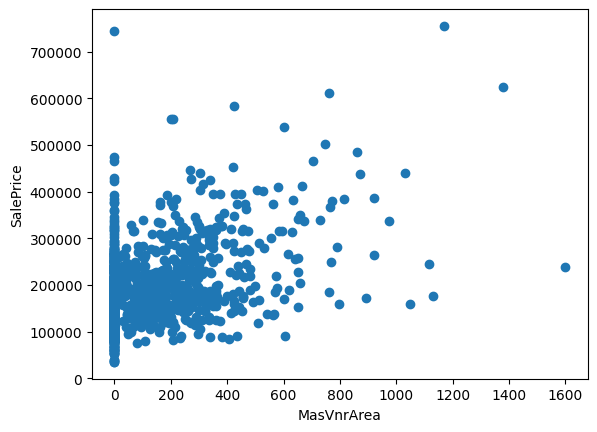

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x = all_data['MasVnrArea'], y = all_data['SalePrice'])
plt.ylabel('SalePrice')
plt.xlabel('MasVnrArea')
plt.show()

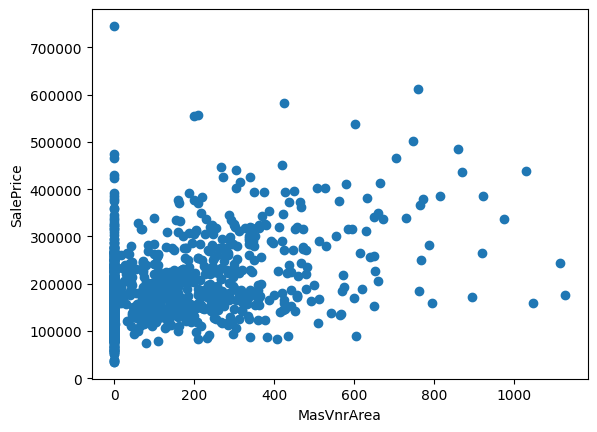

In [ ]:
indices_to_drop = all_data[all_data['MasVnrArea'] > 1150].index
all_data = all_data.drop(indices_to_drop, axis=0)

fig, ax = plt.subplots()
ax.scatter(x = all_data['MasVnrArea'], y = all_data['SalePrice'])
plt.ylabel('SalePrice')
plt.xlabel('MasVnrArea')
plt.show()

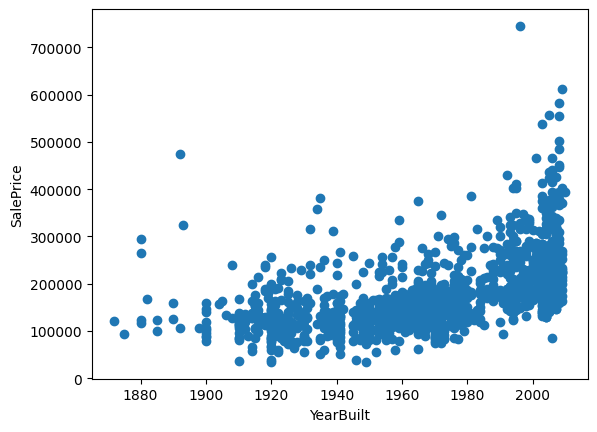

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x = all_data['YearBuilt'], y = all_data['SalePrice'])
plt.ylabel('SalePrice')
plt.xlabel('YearBuilt')
plt.show()

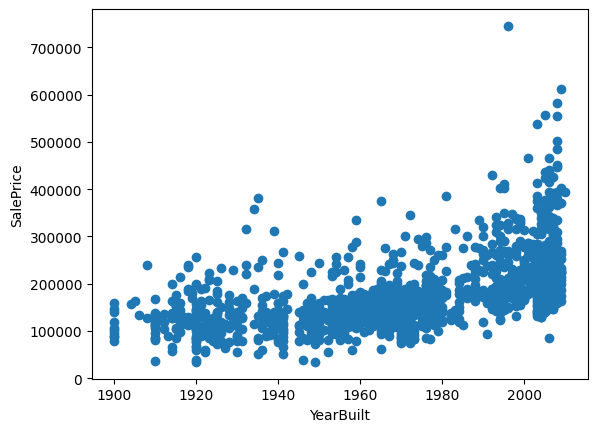

In [ ]:
indices_to_drop = all_data[all_data['YearBuilt'] < 1900].index
all_data = all_data.drop(indices_to_drop, axis=0)

fig, ax = plt.subplots()
ax.scatter(x = all_data['YearBuilt'], y = all_data['SalePrice'])
plt.ylabel('SalePrice')
plt.xlabel('YearBuilt')
plt.show()

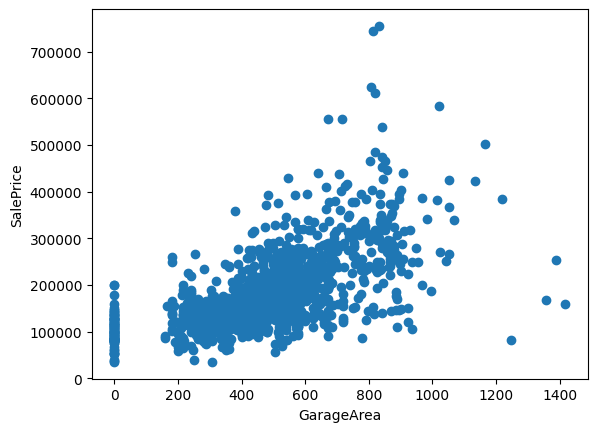

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x = df['GarageArea'], y = df['SalePrice'])
plt.ylabel('SalePrice')
plt.xlabel('GarageArea')
plt.show()

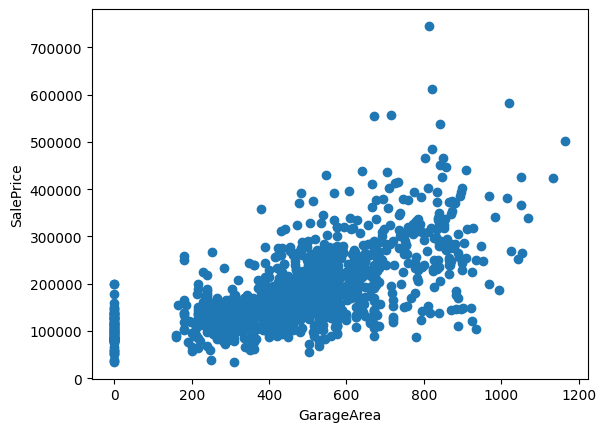

In [ ]:
indices_to_drop = all_data[all_data['GarageArea'] > 1200].index
all_data = all_data.drop(indices_to_drop, axis=0)

fig, ax = plt.subplots()
ax.scatter(x = all_data['GarageArea'], y = all_data['SalePrice'])
plt.ylabel('SalePrice')
plt.xlabel('GarageArea')
plt.show()

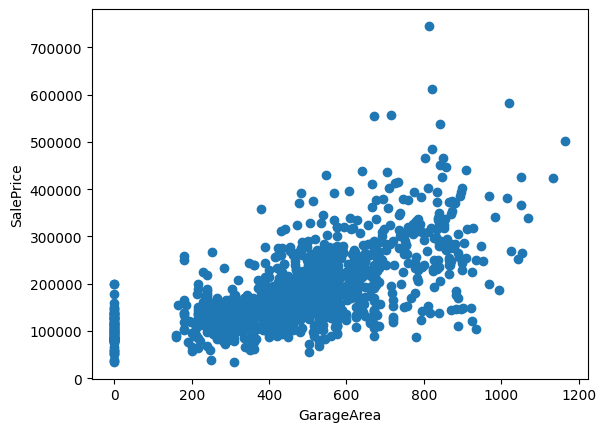

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x = all_data['GarageArea'], y = all_data['SalePrice'])
plt.ylabel('SalePrice')
plt.xlabel('GarageArea')
plt.show()

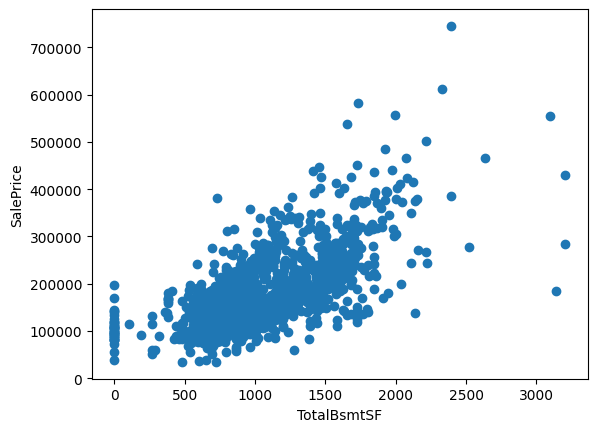

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x =(all_data['TotalBsmtSF']), y = all_data['SalePrice'])
plt.ylabel('SalePrice')
plt.xlabel('TotalBsmtSF')
plt.show()

In [ ]:
indices_to_drop = all_data[all_data['TotalBsmtSF'] > 3000].index
all_data = all_data.drop(indices_to_drop, axis=0)

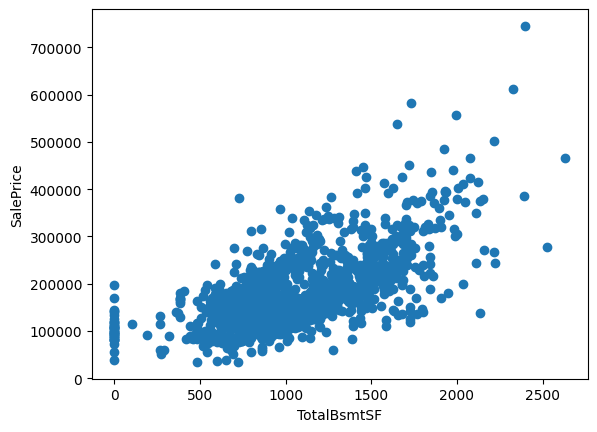

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x =(all_data['TotalBsmtSF']), y = all_data['SalePrice'])
plt.ylabel('SalePrice')
plt.xlabel('TotalBsmtSF')
plt.show()

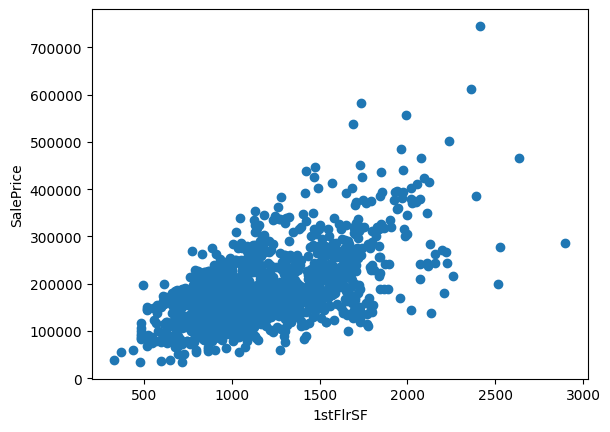

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x =(all_data['1stFlrSF']), y = all_data['SalePrice'])
plt.ylabel('SalePrice')
plt.xlabel('1stFlrSF')
plt.show()

In [ ]:
indices_to_drop = all_data[all_data['1stFlrSF'] > 2500].index
all_data = all_data.drop(indices_to_drop, axis=0)

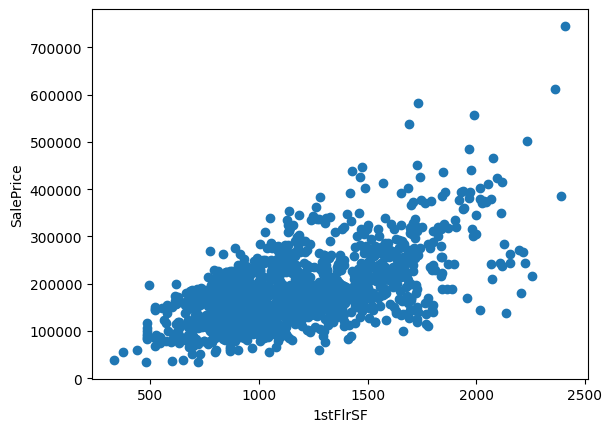

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x =(all_data['1stFlrSF']), y = all_data['SalePrice'])
plt.ylabel('SalePrice')
plt.xlabel('1stFlrSF')
plt.show()

In [ ]:
def plot_cat(feature):
  sns.countplot(data=all_data,x=feature)
  ax=sns.countplot(data=all_data,x=feature)

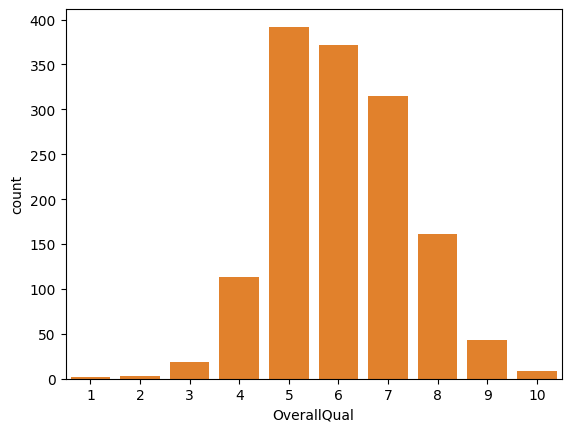

In [ ]:
plot_cat('OverallQual')

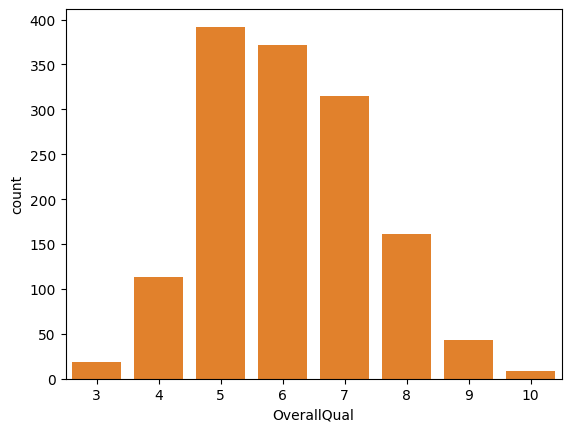

In [ ]:
all_data = all_data.drop(all_data[all_data['OverallQual'] <= 2].index)
plot_cat('OverallQual')

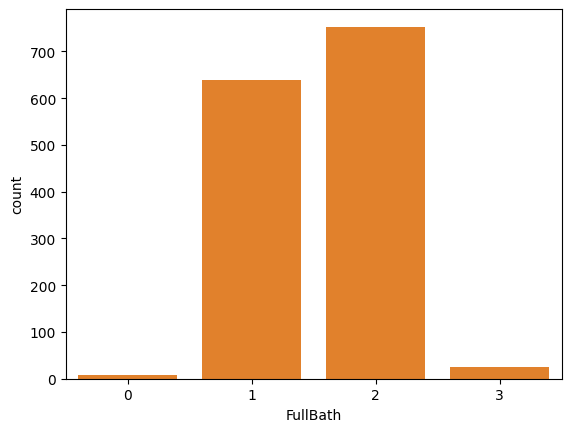

In [ ]:
plot_cat('FullBath')

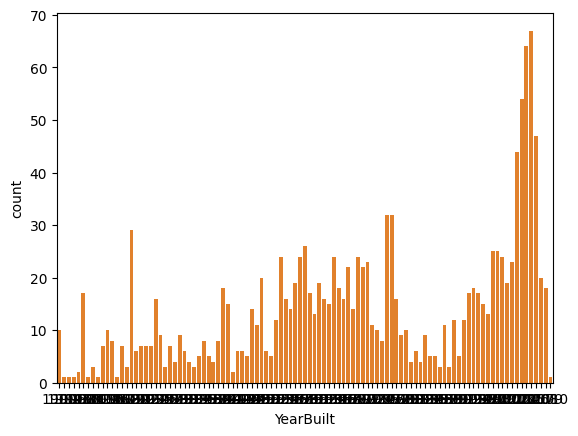

In [ ]:
plot_cat('YearBuilt')

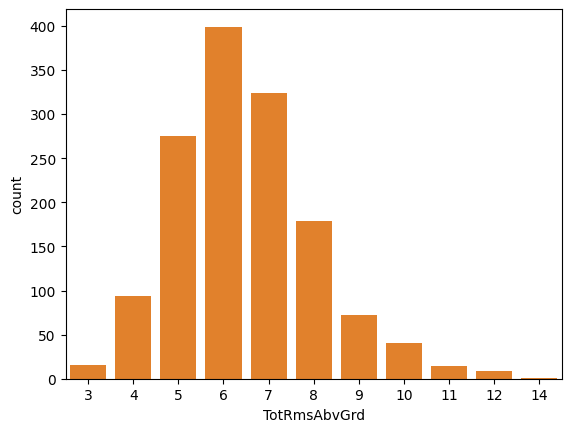

In [ ]:
plot_cat('TotRmsAbvGrd')

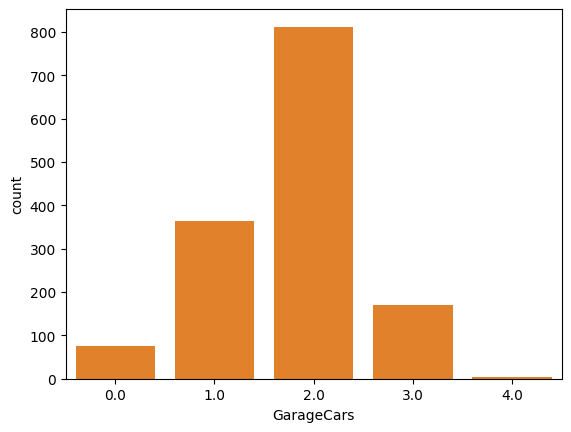

In [ ]:
plot_cat('GarageCars')

In [ ]:
all_data

,MSZoning,LotShape,LandContour,LotConfig,Neighborhood,Condition2,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,TotalBsmtSF,Heating,Electrical,1stFlrSF,GrLivArea,FullBath,KitchenQual,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,GarageQual,SaleType,SaleCondition,SalePrice
0,RL,Reg,Lvl,Inside,CollgCr,Norm,7,2003,2003,196.0,Gd,TA,PConc,Gd,TA,No,856.0,GasA,SBrkr,856,1710,2,Gd,8,0,2003.0,2.0,548.0,TA,WD,Normal,208500.0
1,RL,Reg,Lvl,FR2,Veenker,Norm,6,1976,1976,0.0,TA,TA,CBlock,Gd,TA,Gd,1262.0,GasA,SBrkr,1262,1262,2,TA,6,1,1976.0,2.0,460.0,TA,WD,Normal,181500.0
2,RL,IR1,Lvl,Inside,CollgCr,Norm,7,2001,2002,162.0,Gd,TA,PConc,Gd,TA,Mn,920.0,GasA,SBrkr,920,1786,2,Gd,6,1,2001.0,2.0,608.0,TA,WD,Normal,223500.0
3,RL,IR1,Lvl,Corner,Crawfor,Norm,7,1915,1970,0.0,TA,TA,BrkTil,TA,Gd,No,756.0,GasA,SBrkr,961,1717,1,Gd,7,1,1998.0,3.0,642.0,TA,WD,Abnorml,140000.0
4,RL,IR1,Lvl,FR2,NoRidge,Norm,8,2000,2000,350.0,Gd,TA,PConc,Gd,TA,Av,1145.0,GasA,SBrkr,1145,2198,2,Gd,9,1,2000.0,3.0,836.0,TA,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Reg,Lvl,Inside,Gilbert,Norm,6,1999,2000,0.0,TA,TA,PConc,Gd,TA,No,953.0,GasA,SBrkr,953,1647,2,TA,7,1,1999.0,2.0,460.0,TA,WD,Normal,175000.0
1456,RL,Reg,Lvl,Inside,NWAmes,Norm,6,1978,1988,119.0,TA,TA,CBlock,Gd,TA,No,1542.0,GasA,SBrkr,2073,2073,2,TA,7,2,1978.0,2.0,500.0,TA,WD,Normal,210000.0
1457,RL,Reg,Lvl,Inside,Crawfor,Norm,7,1941,2006,0.0,Ex,Gd,Stone,TA,Gd,No,1152.0,GasA,SBrkr,1188,2340,2,Gd,9,2,1941.0,1.0,252.0,TA,WD,Normal,266500.0
1458,RL,Reg,Lvl,Inside,NAmes,Norm,5,1950,1996,0.0,TA,TA,CBlock,TA,TA,Mn,1078.0,GasA,FuseA,1078,1078,1,Gd,5,0,1950.0,1.0,240.0,TA,WD,Normal,142125.0
